## **CASO PRÁCTICO CLINICA**

In [39]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### Como primera etapa exploratoria, se evalúa la dimensión de los datos (número de observaciones y variables), lo cual permite identificar el tamaño muestral disponible y la estructura del conjunto de datos.

In [40]:
#Lectura del archivo
ruta_lima   = r"C:/Users/PROPIETARIO/Desktop/PROGRAMACIÓN/PRACTICANDO-PYTHON/PROYECTO CLINICA/Establecimiento a nivel Lima.xls"
ruta_callao = r"C:/Users/PROPIETARIO/Desktop/PROGRAMACIÓN/PRACTICANDO-PYTHON/PROYECTO CLINICA/Establecimiento a nivel Callao.xls"
data_lima   = pd.read_excel(ruta_lima)
data_callao = pd.read_excel(ruta_callao)

print(f"✅ Lima   → {data_lima.shape[0]:,} filas | {data_lima.shape[1]} columnas")
print(f"✅ Callao → {data_callao.shape[0]:,} filas | {data_callao.shape[1]} columnas")

✅ Lima   → 9,687 filas | 31 columnas
✅ Callao → 882 filas | 31 columnas


In [41]:
data_total = pd.concat([data_lima, data_callao], ignore_index=True)
print(f"\n✅ Total combinado: {data_total.shape[0]:,} filas")
print(data_total['Departamento'].value_counts())


✅ Total combinado: 10,569 filas
Departamento
LIMA      9687
CALLAO     882
Name: count, dtype: int64


### Estableciendo por Distritos

##### Realicé limpieza y estandarización de datos para asegurar consistencia, luego segmenté los distritos de Lima en zonas estratégicas. Finalmente, generé una variable de zona y validé registros sin clasificar, lo que permitió mejorar el análisis geográfico y la toma de decisiones.

In [42]:
# PASO 2: LIMPIAR
# ─────────────────────────────────────────
data_total['Distrito']      = data_total['Distrito'].str.upper().str.strip()
data_total['Departamento']  = data_total['Departamento'].str.upper().str.strip()
data_total['Estado']        = data_total['Estado'].str.upper().str.strip()
data_total['Clasificación'] = data_total['Clasificación'].str.upper().str.strip()
data_total['Clasificación'] = data_total['Clasificación'].fillna('SIN CLASIFICAR')

# ─────────────────────────────────────────
# PASO 3: DEFINIR ZONAS DE LIMA Y CALLAO
# ─────────────────────────────────────────
zonas_lima = {
    # LIMA NORTE
    'ANCON'                  : 'LIMA NORTE',
    'CARABAYLLO'             : 'LIMA NORTE',
    'COMAS'                  : 'LIMA NORTE',
    'INDEPENDENCIA'          : 'LIMA NORTE',
    'LOS OLIVOS'             : 'LIMA NORTE',
    'PUENTE PIEDRA'          : 'LIMA NORTE',
    'SAN MARTIN DE PORRES'   : 'LIMA NORTE',
    'SANTA ROSA'             : 'LIMA NORTE',

    # LIMA SUR
    'CHORRILLOS'             : 'LIMA SUR',
    'LURIN'                  : 'LIMA SUR',
    'PACHACAMAC'             : 'LIMA SUR',
    'PUCUSANA'               : 'LIMA SUR',
    'PUNTA HERMOSA'          : 'LIMA SUR',
    'PUNTA NEGRA'            : 'LIMA SUR',
    'SAN BARTOLO'            : 'LIMA SUR',
    'SAN JUAN DE MIRAFLORES' : 'LIMA SUR',
    'SANTA MARIA DEL MAR'    : 'LIMA SUR',
    'VILLA EL SALVADOR'      : 'LIMA SUR',
    'VILLA MARIA DEL TRIUNFO': 'LIMA SUR',

    # LIMA CENTRO
    'BARRANCO'               : 'LIMA CENTRO',
    'BREÑA'                  : 'LIMA CENTRO',
    'JESUS MARIA'            : 'LIMA CENTRO',
    'LA MOLINA'              : 'LIMA CENTRO',
    'LA VICTORIA'            : 'LIMA CENTRO',
    'LIMA'                   : 'LIMA CENTRO',
    'LINCE'                  : 'LIMA CENTRO',
    'MAGDALENA DEL MAR'      : 'LIMA CENTRO',
    'MIRAFLORES'             : 'LIMA CENTRO',
    'PUEBLO LIBRE'           : 'LIMA CENTRO',
    'RIMAC'                  : 'LIMA CENTRO',
    'SAN BORJA'              : 'LIMA CENTRO',
    'SAN ISIDRO'             : 'LIMA CENTRO',
    'SAN MIGUEL'             : 'LIMA CENTRO',
    'SANTIAGO DE SURCO'      : 'LIMA CENTRO',
    'SURQUILLO'              : 'LIMA CENTRO',

    # LIMA ESTE
    'ATE'                    : 'LIMA ESTE',
    'CHACLACAYO'             : 'LIMA ESTE',
    'CIENEGUILLA'            : 'LIMA ESTE',
    'EL AGUSTINO'            : 'LIMA ESTE',
    'LURIGANCHO'             : 'LIMA ESTE',
    'SAN JUAN DE LURIGANCHO' : 'LIMA ESTE',
    'SAN LUIS'               : 'LIMA ESTE',
    'SANTA ANITA'            : 'LIMA ESTE',

    # CALLAO
    'BELLAVISTA'                 : 'CALLAO',
    'CALLAO'                     : 'CALLAO',
    'CARMEN DE LA LEGUA REYNOSO' : 'CALLAO',
    'LA PERLA'                   : 'CALLAO',
    'LA PUNTA'                   : 'CALLAO',
    'MI PERU'                    : 'CALLAO',
    'VENTANILLA'                 : 'CALLAO',

    # Agregar estas 4 líneas al diccionario zonas_lima
'CARMEN DE LA LEGUA-REYNOSO' : 'CALLAO',       # con guión
'SURCO'                      : 'LIMA CENTRO',   # alias corto de Santiago de Surco
'SANTA MARIA'                : 'LIMA SUR',      # alias corto de Santa María del Mar
'BARRANCA'                : 'LIMA CENTRO',
}

# ─────────────────────────────────────────
# PASO 4: APLICAR ZONAS
# ─────────────────────────────────────────
data_total['Zona'] = data_total['Distrito'].map(zonas_lima)
data_total['Zona'] = data_total['Zona'].fillna('SIN ZONA')

# Verificar
print("✅ Distribución por Zona:")
print(data_total['Zona'].value_counts())
print(f"\nSin zona asignada: {len(data_total[data_total['Zona'] == 'SIN ZONA'])}")

# Ver cuáles sin zona
sin_zona = data_total[data_total['Zona'] == 'SIN ZONA']['Distrito'].value_counts()
print(f"\nDistritos sin zona:")
print(sin_zona)

✅ Distribución por Zona:
Zona
LIMA CENTRO    4028
LIMA NORTE     1864
LIMA ESTE      1723
LIMA SUR       1348
CALLAO          882
SIN ZONA        724
Name: count, dtype: int64

Sin zona asignada: 724

Distritos sin zona:
Distrito
HUACHO                     159
HUARAL                      87
SAN VICENTE DE CAÑETE       42
CHANCAY                     28
HUAURA                      28
                          ... 
SAN ANDRES DE TUPICOCHA      1
PACARAN                      1
GORGOR                       1
SANTA CRUZ DE FLORES         1
NAVAN                        1
Name: count, Length: 120, dtype: int64


##### Luego se verificamos las zonas sin asignar para no sesgar ninguna información y en ello detectamos 4 líneas que se habian omitido pero lo incluimos para no perder información
'CARMEN DE LA LEGUA-REYNOSO' : 'CALLAO',       
'SURCO'                      : 'LIMA CENTRO',  
'SANTA MARIA'                : 'LIMA SUR',      
'BARRANCA'                : 'LIMA CENTRO',

In [43]:
# ─────────────────────────────────────────
# VER DISTRITOS SIN ZONA ASIGNADA
# ─────────────────────────────────────────
sin_zona_df = (
    data_total[data_total['Zona'] == 'SIN ZONA']
    .groupby(['Departamento', 'Distrito'])
    .size()
    .reset_index(name='Cantidad')
    .sort_values('Cantidad', ascending=False)
)

print(f"⚠️  Total de registros sin zona: {sin_zona_df['Cantidad'].sum()}")
print(f"📍 Distritos únicos sin zona:    {len(sin_zona_df)}\n")
sin_zona_df.style.set_caption("Distritos sin zona asignada") \
                 .background_gradient(subset=['Cantidad'], cmap='Reds') \
                 .set_table_styles([{'selector': 'caption',
                                     'props': [('font-size', '14px'),
                                               ('font-weight', 'bold')]}])

⚠️  Total de registros sin zona: 724
📍 Distritos únicos sin zona:    120



,Departamento,Distrito,Cantidad
36,LIMA,HUACHO,159
46,LIMA,HUARAL,87
95,LIMA,SAN VICENTE DE CAÑETE,42
24,LIMA,CHANCAY,28
49,LIMA,HUAURA,28
38,LIMA,HUALMAY,22
52,LIMA,IMPERIAL,18
82,LIMA,SAN ANTONIO,16
62,LIMA,MALA,16
106,LIMA,SAYAN,16


In [44]:
# ─────────────────────────────────────────
# PASO 5: CONTEO POR ZONA Y DISTRITO
# ─────────────────────────────────────────
resultado = data_total.groupby(['Zona','Distrito'])\
                       .size().reset_index()
resultado.columns = ['Zona', 'Distrito', 'Num_Establecimientos']

from tabulate import tabulate

zonas = ['LIMA NORTE','LIMA SUR','LIMA CENTRO','LIMA ESTE','CALLAO']

for zona in zonas:
    df_zona = resultado[resultado['Zona'] == zona]\
              .sort_values('Num_Establecimientos', ascending=False)
    total = df_zona['Num_Establecimientos'].sum()

    print(f"\n{'='*50}")
    print(f"📍 {zona} — Total: {total:,} establecimientos")
    print(f"{'='*50}")
    print(tabulate(df_zona[['Distrito','Num_Establecimientos']],
                   headers=['Distrito', 'N° Establec.'],
                   tablefmt='rounded_outline',
                   showindex=False))


📍 LIMA NORTE — Total: 1,864 establecimientos
╭──────────────────────┬────────────────╮
│ Distrito             │   N° Establec. │
├──────────────────────┼────────────────┤
│ LOS OLIVOS           │            634 │
│ SAN MARTIN DE PORRES │            401 │
│ COMAS                │            376 │
│ PUENTE PIEDRA        │            217 │
│ CARABAYLLO           │            124 │
│ INDEPENDENCIA        │             86 │
│ ANCON                │             17 │
│ SANTA ROSA           │              9 │
╰──────────────────────┴────────────────╯

📍 LIMA SUR — Total: 1,348 establecimientos
╭─────────────────────────┬────────────────╮
│ Distrito                │   N° Establec. │
├─────────────────────────┼────────────────┤
│ SAN JUAN DE MIRAFLORES  │            377 │
│ VILLA EL SALVADOR       │            313 │
│ CHORRILLOS              │            242 │
│ VILLA MARIA DEL TRIUNFO │            211 │
│ LURIN                   │             92 │
│ PACHACAMAC              │             74 │
│

##### Los Distritos sin Zona se dejan a un lado ya que no lo tomaremos en cuenta en el análisis porque segun la segmentación esas zonas no se consideraria 

In [45]:
# Establecimientos NO clasificados (SIN ZONA)
sin_zona_detalle = (
    data_total[data_total['Zona'] == 'SIN ZONA']
    .groupby(['Departamento', 'Distrito'])
    .size()
    .reset_index(name='Cantidad')
    .sort_values('Cantidad', ascending=False)
)

total_sin_zona = sin_zona_detalle['Cantidad'].sum()

print(f"⚠️  Total establecimientos NO contados: {total_sin_zona:,}")
print(f"📍 Distritos únicos sin clasificar:     {len(sin_zona_detalle)}\n")
print(sin_zona_detalle.to_string(index=False))

⚠️  Total establecimientos NO contados: 724
📍 Distritos únicos sin clasificar:     120

Departamento                     Distrito  Cantidad
        LIMA                       HUACHO       159
        LIMA                       HUARAL        87
        LIMA        SAN VICENTE DE CAÑETE        42
        LIMA                      CHANCAY        28
        LIMA                       HUAURA        28
        LIMA                      HUALMAY        22
        LIMA                     IMPERIAL        18
        LIMA                  SAN ANTONIO        16
        LIMA                         MALA        16
        LIMA                        SAYAN        16
        LIMA                         SUPE        13
        LIMA                         OYON        12
        LIMA                    PARAMONGA        12
        LIMA                       CHILCA        10
        LIMA                    PATIVILCA        10
        LIMA               NUEVO IMPERIAL         8
        LIMA                

### Gráfico por Distritos

##### El análisis de Lima Metropolitana muestra que Lima Centro concentra la mayor cantidad de establecimientos de salud (4,028), muy por encima de Lima Norte (1,864), Lima Este (1,723) y Lima Sur (1,348). Esto confirma una alta centralización de la oferta.

✅ Total tras filtro: 9,845


C:\Users\PROPIETARIO\AppData\Local\Temp\ipykernel_11268\262468432.py:92: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PROPIETARIO\AppData\Local\Temp\ipykernel_11268\262468432.py:93: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.savefig('Establecimientos de Salud por Zona y Distrito.png',
c:\Users\PROPIETARIO\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


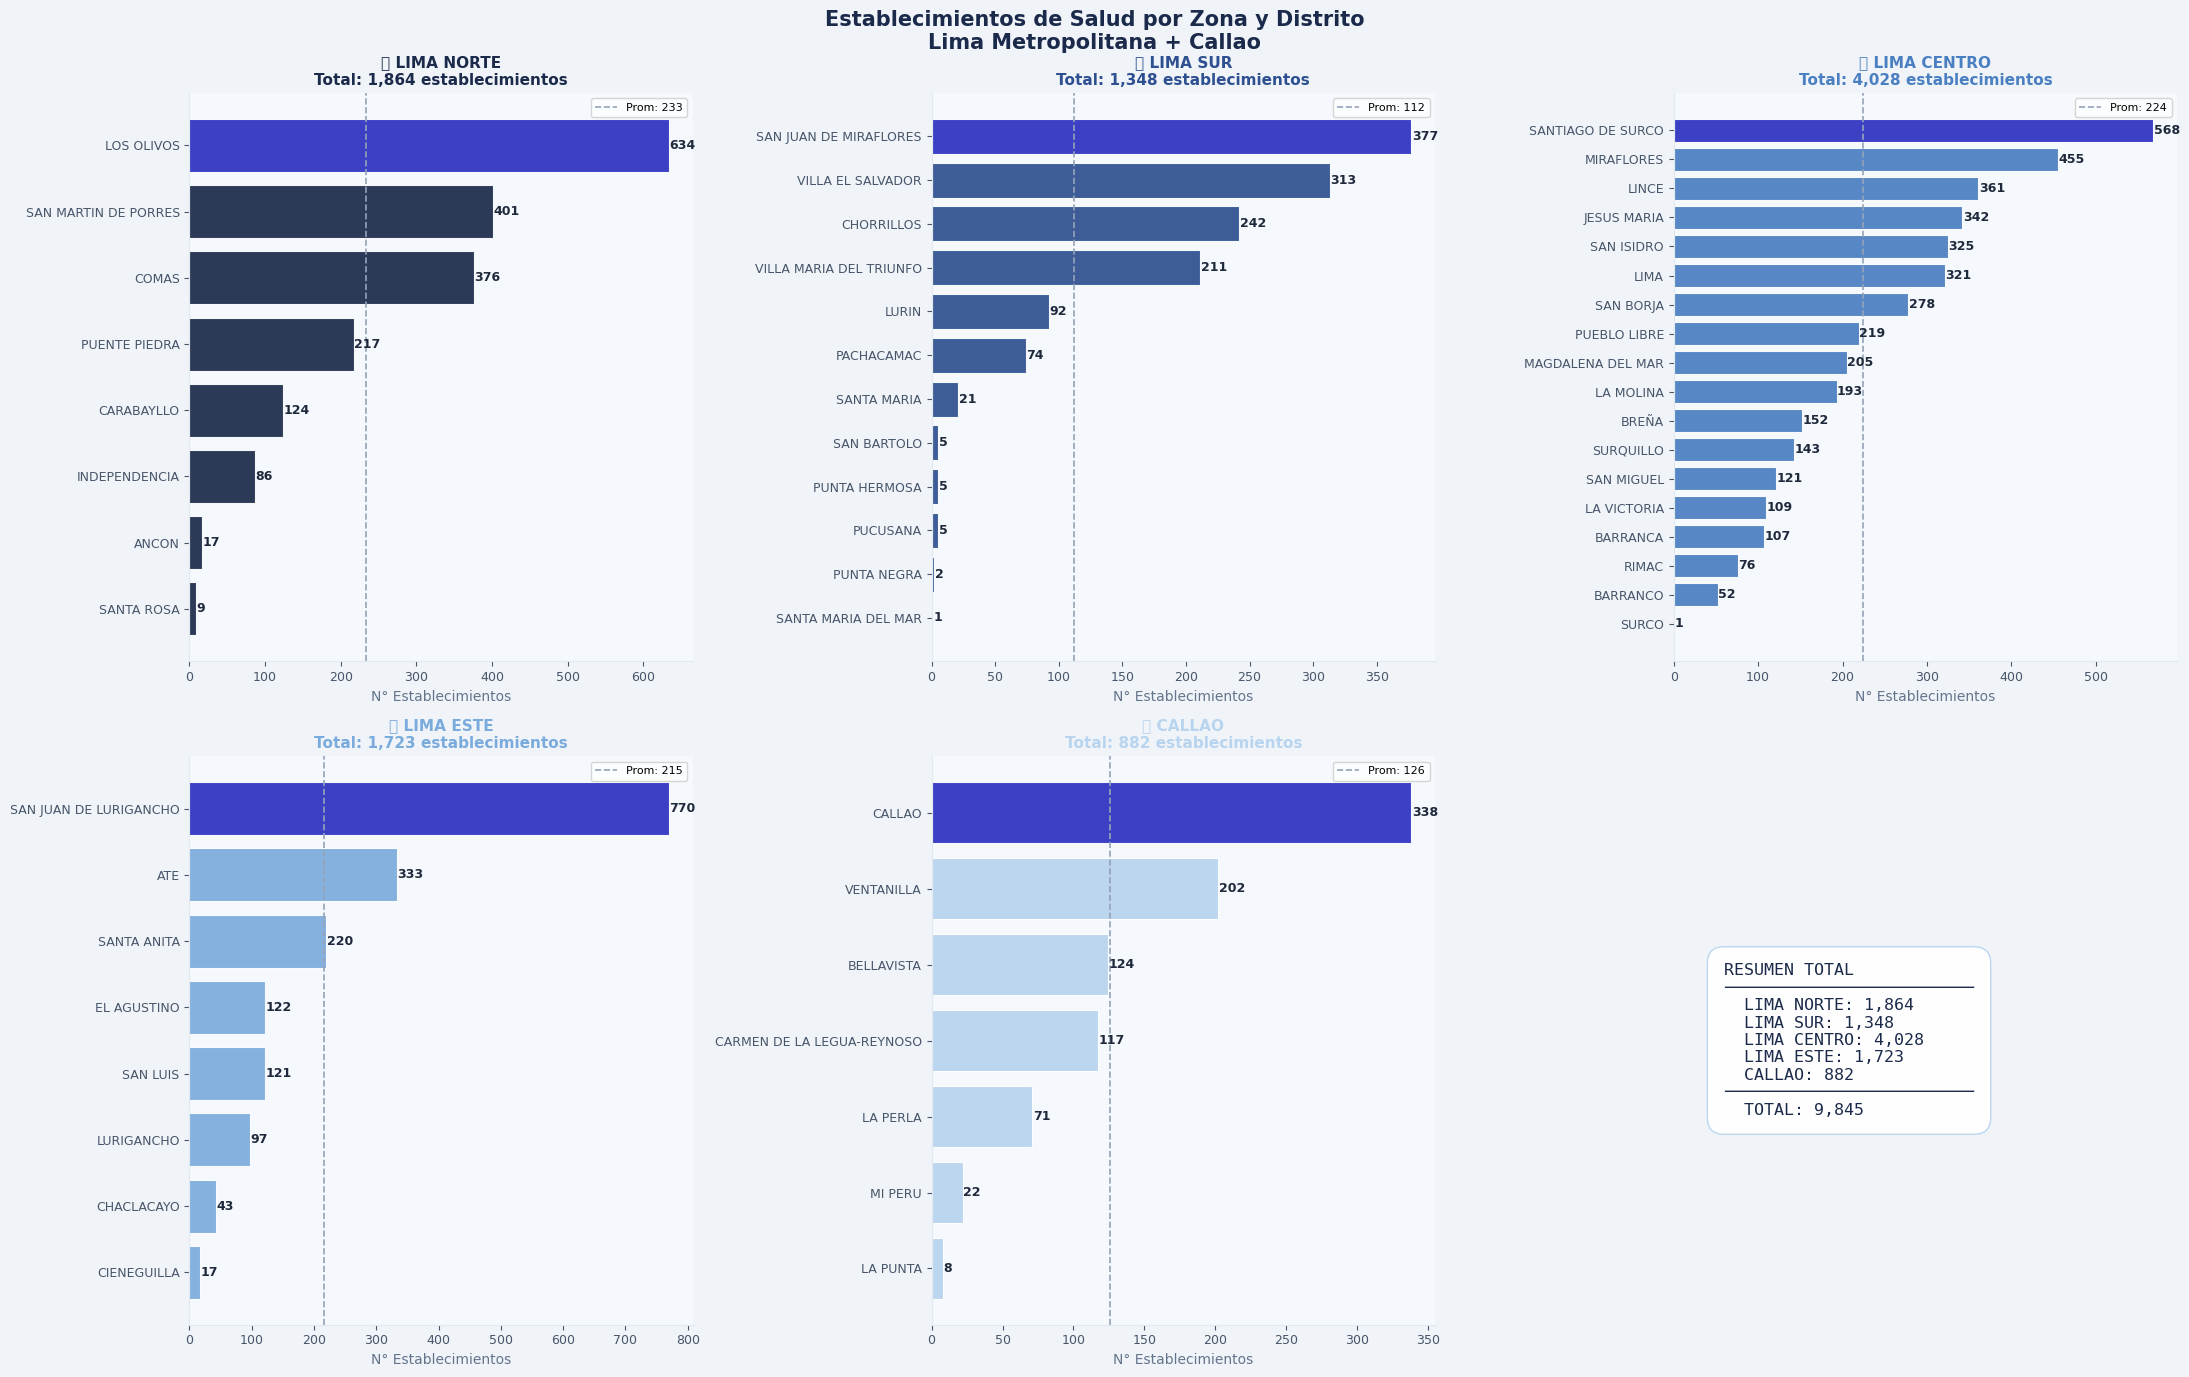

✅ Guardada como Establecimientos de Salud por Zona y Distrito.png


In [46]:
# ── FILTRO —
zonas_validas = ['LIMA NORTE', 'LIMA SUR', 'LIMA CENTRO', 'LIMA ESTE', 'CALLAO']

resultado = resultado[resultado['Zona'].isin(zonas_validas)].copy()
zonas     = zonas_validas  # sobreescribe zonas también

print(f"✅ Total tras filtro: {resultado['Num_Establecimientos'].sum():,}")
#
# ─────────────────────────────────────────
# PALETA AZUL CORPORATIVO ELEGANTE
# ─────────────────────────────────────────
colores_zona = {
    'LIMA NORTE' : '#1B2A4A',  # azul marino
    'LIMA SUR'   : '#2E5090',  # azul royal
    'LIMA CENTRO': '#4A7FC1',  # azul medio
    'LIMA ESTE'  : '#7AABDC',  # azul suave
    'CALLAO'     : '#B8D4EE',  # azul muy suave
}
color_maximo = "#2B30C0"       # rojo acento
color_fondo  = '#F5F8FC'
color_general= '#F0F4F9'

# ─────────────────────────────────────────
# GRÁFICA COMPLETA
# ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.patch.set_facecolor(color_general)
fig.suptitle('Establecimientos de Salud por Zona y Distrito\n'
             'Lima Metropolitana + Callao',
             fontsize=15, fontweight='bold', color='#1B2A4A')

posiciones = [(0,0),(0,1),(0,2),(1,0),(1,1)]

for zona, pos in zip(zonas, posiciones):
    ax = axes[pos[0], pos[1]]
    color = colores_zona[zona]

    df_zona = resultado[resultado['Zona'] == zona]\
              .sort_values('Num_Establecimientos', ascending=True)
    total = df_zona['Num_Establecimientos'].sum()

    bars = ax.barh(df_zona['Distrito'],
                   df_zona['Num_Establecimientos'],
                   color=color, alpha=0.92,
                   edgecolor='white', linewidth=0.8)

    ax.set_title(f'📍 {zona}\nTotal: {total:,} establecimientos',
                 fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('N° Establecimientos', color='#64748B')
    ax.set_facecolor(color_fondo)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#E2E8F0')
    ax.spines['bottom'].set_color('#E2E8F0')
    ax.tick_params(colors='#475569', labelsize=9)

    # Línea promedio
    promedio = df_zona['Num_Establecimientos'].mean()
    ax.axvline(x=promedio, color='#94A3B8', linestyle='--',
               linewidth=1.2, label=f'Prom: {promedio:.0f}')
    ax.legend(fontsize=8)

    # Resaltar máximo + etiquetas
    max_val = df_zona['Num_Establecimientos'].max()
    for bar, v in zip(bars, df_zona['Num_Establecimientos']):
        if v == max_val:
            bar.set_color(color_maximo)
            bar.set_edgecolor('white')
        ax.text(v + 0.5, bar.get_y() + bar.get_height()/2,
                f'{v:,}', va='center', fontsize=9,
                fontweight='bold', color='#1E293B')

# Ocultar subplot vacío
axes[1, 2].axis('off')
axes[1, 2].set_facecolor(color_general)

# Resumen en espacio vacío
totales = resultado.groupby('Zona')['Num_Establecimientos'].sum()
resumen = "\n".join([f"  {z}: {totales[z]:,}" 
                     for z in zonas if z in totales])
axes[1, 2].text(0.1, 0.5,
    f"RESUMEN TOTAL\n{'─'*25}\n{resumen}\n{'─'*25}\n"
    f"  TOTAL: {totales.sum():,}",
    transform=axes[1, 2].transAxes,
    fontsize=12, verticalalignment='center',
    fontfamily='monospace', color='#1B2A4A',
    bbox=dict(boxstyle='round,pad=1',
              facecolor='white',
              edgecolor='#B8D4EE',
              alpha=0.95))

plt.tight_layout()
plt.savefig('Establecimientos de Salud por Zona y Distrito.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardada como Establecimientos de Salud por Zona y Distrito.png")

In [ ]:
# EJECUTA
!pip install folium
!pip install geopandas
!pip install requests

### GRAFICA POR MAPA

##### El mapa muestra que Lima Centro concentra la mayor cantidad de establecimientos, mientras que Norte, Este y Sur presentan menor cobertura, evidenciando una distribución centralizada

In [48]:

# usar coordenadas manuales con folium
# ─────────────────────────────────────────
import folium
import pandas as pd

# Conteo por zona
conteo_zona = data_total.groupby('Zona').size().reset_index()
conteo_zona.columns = ['Zona', 'Num_Establecimientos']

# Coordenadas centrales de cada zona
coordenadas = {
    'LIMA NORTE' : [-11.9338, -77.0625],
    'LIMA SUR'   : [-12.1900, -76.9700],
    'LIMA CENTRO': [-12.0800, -77.0500],
    'LIMA ESTE'  : [-12.0200, -76.9500],
    'CALLAO'     : [-12.0566, -77.1181],
}

colores_zona = {
    'LIMA NORTE' : 'darkblue',
    'LIMA SUR'   : 'blue',
    'LIMA CENTRO': 'cadetblue',
    'LIMA ESTE'  : 'lightblue',
    'CALLAO'     : 'purple',
}

# Crear mapa
mapa = folium.Map(
    location=[-12.0464, -77.0428],
    zoom_start=11,
    tiles='CartoDB positron'
)

# Agregar círculos por zona
for zona, coords in coordenadas.items():
    num = conteo_zona[conteo_zona['Zona'] == zona]['Num_Establecimientos']
    n   = int(num.values[0]) if len(num) > 0 else 0

    folium.CircleMarker(
        location=coords,
        radius=n / 30,            # tamaño proporcional
        color=colores_zona[zona],
        fill=True,
        fill_color=colores_zona[zona],
        fill_opacity=0.7,
        popup=folium.Popup(
            f"<b>{zona}</b><br>"
            f"Establecimientos: {n:,}",
            max_width=200
        ),
        tooltip=f"{zona}: {n:,} establecimientos"
    ).add_to(mapa)

    # Etiqueta encima del círculo
    folium.Marker(
        location=coords,
        icon=folium.DivIcon(
            html=f'<div style="font-size:10px; font-weight:bold; '
                 f'color:#1B2A4A; white-space:nowrap;">'
                 f'{zona}<br>{n:,}</div>',
            icon_size=(120, 40)
        )
    ).add_to(mapa)

# Leyenda
leyenda = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:15px; border-radius:10px;
     border:2px solid #B8D4EE; font-size:12px; font-family:Arial">
    <b style="color:#1B2A4A">🏥 Zonas Lima </b><br><br>
    ⚫ Tamaño = N° establecimientos<br><br>
    🔵 Lima Norte<br>
    🔵 Lima Sur<br>
    🔵 Lima Centro<br>
    🔵 Lima Este<br>
    🟣 Callao
</div>
"""
mapa.get_root().html.add_child(folium.Element(leyenda))

# Guardar
ruta = r"C:\Users\PROPIETARIO\Desktop\PROGRAMACIÓN\PRACTICANDO-PYTHON\PROYECTO CLINICA\mapa_zonas_lima.html"
mapa.save(ruta)
print("✅ Mapa guardado — ábrelo en Chrome")

✅ Mapa guardado — ábrelo en Chrome


In [49]:
import webbrowser

ruta = r"C:\Users\PROPIETARIO\Desktop\PROGRAMACIÓN\PRACTICANDO-PYTHON\PROYECTO CLINICA\mapa_zonas_lima.html"
webbrowser.open(ruta)
print("✅ Abriendo en Chrome...")

✅ Abriendo en Chrome...


##### Lima Centro concentra la mayor proporción de establecimientos de salud con 40.9% (4,028), seguido por Lima Norte (18.9%) y Lima Este (17.5%). En contraste, Lima Sur (13.7%) y Callao (9%) presentan menor participación.

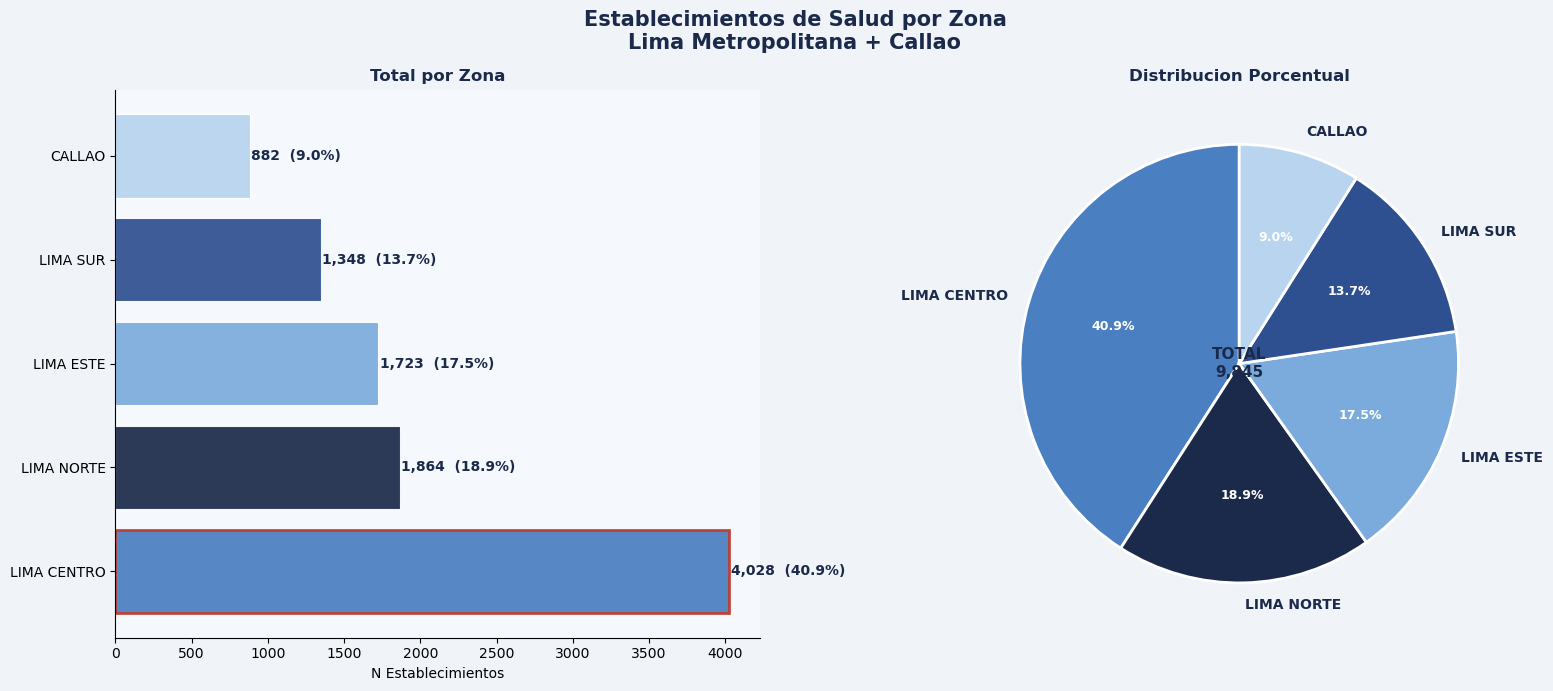

Guardada como grafica_zonas_lima.png


In [50]:

import matplotlib.pyplot as plt

colores_zona = {
    'LIMA NORTE' : '#1B2A4A',
    'LIMA SUR'   : '#2E5090',
    'LIMA CENTRO': '#4A7FC1',
    'LIMA ESTE'  : '#7AABDC',
    'CALLAO'     : '#B8D4EE',
}

conteo_zona = data_total.groupby('Zona').size().reset_index()
conteo_zona.columns = ['Zona', 'Num_Establecimientos']
conteo_zona = conteo_zona[conteo_zona['Zona'] != 'SIN ZONA']\
              .sort_values('Num_Establecimientos', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#F0F4F9')
fig.suptitle('Establecimientos de Salud por Zona\nLima Metropolitana + Callao',
             fontsize=15, fontweight='bold', color='#1B2A4A')

# GRÁFICA 1: Barras
ax1 = axes[0]
ax1.set_facecolor('#F5F8FC')
bars = ax1.barh(conteo_zona['Zona'],
                conteo_zona['Num_Establecimientos'],
                color=[colores_zona[z] for z in conteo_zona['Zona']],
                edgecolor='white', linewidth=0.8, alpha=0.92)

ax1.set_title('Total por Zona', fontsize=12,
              fontweight='bold', color='#1B2A4A')
ax1.set_xlabel('N Establecimientos')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

total_general = conteo_zona['Num_Establecimientos'].sum()
max_val = conteo_zona['Num_Establecimientos'].max()

for bar, (_, row) in zip(bars, conteo_zona.iterrows()):
    v   = row['Num_Establecimientos']
    pct = v / total_general * 100
    if v == max_val:
        bar.set_edgecolor('#C0392B')
        bar.set_linewidth(2)
    ax1.text(v + 10, bar.get_y() + bar.get_height()/2,
             f'{v:,}  ({pct:.1f}%)',
             va='center', fontsize=10, fontweight='bold',
             color='#1B2A4A')

# GRÁFICA 2: Pie
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    conteo_zona['Num_Establecimientos'],
    labels=conteo_zona['Zona'],
    colors=[colores_zona[z] for z in conteo_zona['Zona']],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)

for text in texts:
    text.set_fontsize(10)
    text.set_fontweight('bold')
    text.set_color('#1B2A4A')

for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax2.set_title('Distribucion Porcentual', fontsize=12,
              fontweight='bold', color='#1B2A4A')

ax2.text(0, 0, f'TOTAL\n{total_general:,}',
         ha='center', va='center',
         fontsize=11, fontweight='bold', color='#1B2A4A')

plt.tight_layout()
plt.savefig('grafica_zonas_lima.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardada como grafica_zonas_lima.png")
